In [ ]:
import pandas as pd
import os

file_path = "/content/drive/MyDrive/Patient_Reviews_Dataset.csv"

if os.path.exists(file_path):
  print("File exists.")
else:
  print("File does not exist.")

File exists.


In [ ]:
df = pd.read_csv(file_path)

# EDA part
There is no missing values.

In [ ]:
df.isnull().sum()

,0
Review,0
Rating,0
Sentiment,0
Location,0
Month,0


While analyzing the dataset to see its content, I found out that for some reviews where the Rating and the sentiment was sometimes not matching. For example, some reviews have a 5 rate but a negative sentiment which is not normal.

In [ ]:
df.sample(30)

,Review,Rating,Sentiment,Location,Month
479,Excellent service! The staff was friendly and ...,4,Positive,"Rubenview, SD",May
144,I felt very comfortable discussing my health i...,5,Positive,"Jessicahaven, WY",May
205,The doctor was very attentive and listened to ...,5,Positive,"Lake Jenniferfurt, AR",May
461,Friendly and knowledgeable staff made my visit...,5,Positive,"Lopeztown, MS",June
42,I had a great experience. The facility was cle...,5,Positive,"Markfort, FL",May
169,Great bedside manner and thorough explanation ...,5,Positive,"South Andrew, NJ",May
232,I felt very comfortable discussing my health i...,5,Positive,"Lopeztown, MS",May
469,I felt ignored during my consultation. Very un...,4,Negative,"Jessicahaven, WY",June
64,I had a great experience. The facility was cle...,5,Positive,"Josephberg, NJ",May
154,The doctor was very attentive and listened to ...,5,Positive,"Petersonchester, MT",July


So I ran this code to see how many inconsistent reviews exist and I found that 20% of the dataset which is too much to ignore.

In [ ]:
inconsistent = df[
    ((df["Rating"] >= 4) & (df["Sentiment"] == "Negative")) |
    ((df["Rating"] <= 2) & (df["Sentiment"] == "Positive"))
]

print("Number of inconsistent reviews:", len(inconsistent))

Number of inconsistent reviews: 97


In [ ]:
print(f"Percentage: {len(inconsistent)/len(df)*100} %")

Percentage: 19.400000000000002 %


So, to handle the issue,  I used VADER which is a sentiment analysis
tool that gives a score based on the sentiment of the text. Thanks
to this score, I was able to find the rating by using a formula and convert the vader score to a grade between 1 and 5.

In [ ]:
inconsistent_mask = (
    ((df["Rating"] >= 4) & (df["Sentiment"] == "Negative")) |
    ((df["Rating"] <= 2) & (df["Sentiment"] == "Positive"))
)

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

df["vader_score"] = None  # colonne vide

df.loc[inconsistent_mask, "vader_score"] = df.loc[inconsistent_mask, "Review"] \
    .apply(lambda x: sia.polarity_scores(x)["compound"])

df["Rating_Adjusted"] = df["Rating"]  # on copie l’original

df.loc[inconsistent_mask, "Rating_Adjusted"] = (
    ((df.loc[inconsistent_mask, "vader_score"] + 1) / 2) * 4 + 1
).round().astype(int)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


This added 2 new columns and fixed the issue of the rating !!

In [ ]:
df.sample(20)

,Review,Rating,Sentiment,Location,Month,vader_score,Rating_Adjusted
109,Highly recommended! The treatment was effectiv...,5,Positive,"New Alfred, MN",June,None,5
101,Billing issues were a nightmare. Hidden charge...,1,Negative,"North Jose, NH",May,None,1
186,The staff was rude and unhelpful. Would not re...,4,Negative,"Jessicahaven, WY",October,-0.6261,1
279,The appointment process was seamless and effic...,4,Positive,"Petersonchester, MT",May,None,4
117,Friendly and knowledgeable staff made my visit...,5,Positive,"North Daniel, LA",March,None,5
452,The doctor was very attentive and listened to ...,5,Positive,"North Daniel, LA",December,None,5
200,Highly recommended! The treatment was effectiv...,4,Positive,"Millershire, NC",May,None,4
235,I was very impressed with the level of care I ...,4,Positive,"Fuentesmouth, IN",June,None,4
41,I had to wait for hours despite having an appo...,2,Negative,"South Andrew, NJ",June,None,2
9,The appointment process was seamless and effic...,5,Positive,"Baileyhaven, ID",June,None,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Review           500 non-null    object
 1   Rating           500 non-null    int64 
 2   Sentiment        500 non-null    object
 3   Location         500 non-null    object
 4   Month            500 non-null    object
 5   vader_score      97 non-null     object
 6   Rating_Adjusted  500 non-null    int64 
dtypes: int64(2), object(5)
memory usage: 27.5+ KB


In [ ]:
df['Sentiment'].value_counts()
df['Location'].value_counts()
df['Month'].value_counts()

,count
Month,
June,172
May,133
October,43
July,41
November,39
December,37
March,35


# Text Processing

Added a word count column, character count column and a sentence count column for each review. Also computed average word length and sentence length for each review.

In [ ]:
df["word_count"] = df["Review"].apply(lambda x: len(str(x).split(" ")))
df["char_count"] = df["Review"].apply(lambda x: sum(len(word) for word in str(x).split(" ")))
df["sentence_count"] = df["Review"].apply(lambda x: len(str(x).split(".")))
df["avg_word_length"] = df["char_count"]/df["word_count"]
df["avg_sentence_length"] = df["word_count"]/df["sentence_count"]

print(df[["Review", "word_count"]].head(), "\n")
print(df[["Review", "char_count"]].head(), "\n")
print(df[["Review", "sentence_count"]].head(), "\n")
print(df[["Review", "avg_word_length"]].head(), "\n")
print(df[["Review", "avg_sentence_length"]].head(), "\n")

                                              Review  word_count
0  Billing issues were a nightmare. Hidden charge...           8
1  Communication was terrible. I had to keep foll...           9
2  Great bedside manner and thorough explanation ...           9
3  I had to wait for hours despite having an appo...          10
4  Communication was terrible. I had to keep foll...           9 

                                              Review  char_count
0  Billing issues were a nightmare. Hidden charge...          52
1  Communication was terrible. I had to keep foll...          47
2  Great bedside manner and thorough explanation ...          59
3  I had to wait for hours despite having an appo...          45
4  Communication was terrible. I had to keep foll...          47 

                                              Review  sentence_count
0  Billing issues were a nightmare. Hidden charge...               3
1  Communication was terrible. I had to keep foll...               3
2  Great 

In [ ]:
df.sample(5)

,Review,Rating,Sentiment,Location,Month,vader_score,Rating_Adjusted,word_count,char_count,sentence_count,avg_word_length,avg_sentence_length
82,Not satisfied with the treatment. The doctor s...,2,Negative,"Lake Robert, WA",May,None,2,11,53,3,4.818182,3.666667
361,Highly recommended! The treatment was effectiv...,4,Positive,"North Daniel, LA",June,None,4,8,52,2,6.500000,4.000000
203,Highly recommended! The treatment was effectiv...,4,Positive,"Markfort, FL",May,None,4,8,52,2,6.500000,4.000000
477,"Poor hygiene standards in the clinic, very con...",4,Negative,"Lopeztown, MS",June,-0.4767,2,8,47,2,5.875000,4.000000
205,The doctor was very attentive and listened to ...,5,Positive,"Lake Jenniferfurt, AR",May,None,5,11,52,2,4.727273,5.500000


# Data Visualization

Number of reviews per rating: Rating_Adjusted
4    138
5    131
2     94
1     69
3     68
Name: count, dtype: int64



<Axes: title={'center': 'Number of reviews per rating'}, xlabel='Rating_Adjusted'>

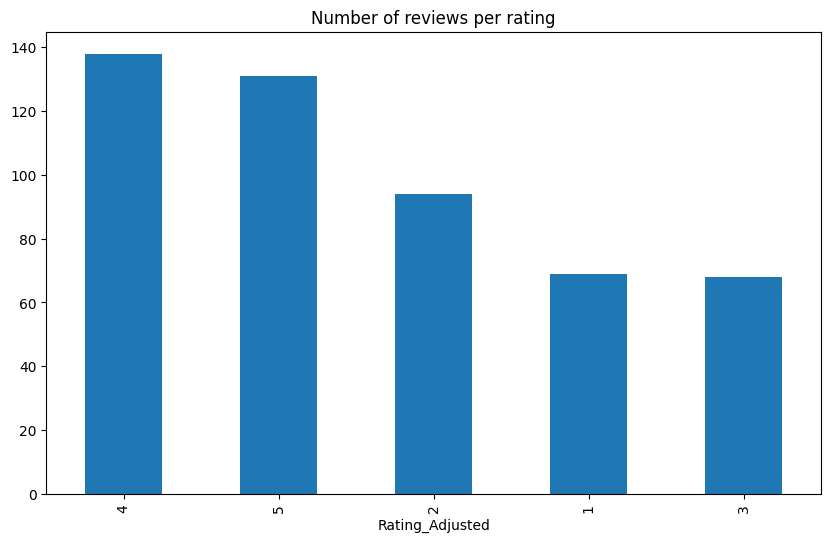

In [ ]:
review_ratings = df["Rating_Adjusted"].value_counts()

print(f"Number of reviews per rating: {review_ratings}\n")

review_ratings.plot(kind="bar", figsize=(10, 6), title="Number of reviews per rating")

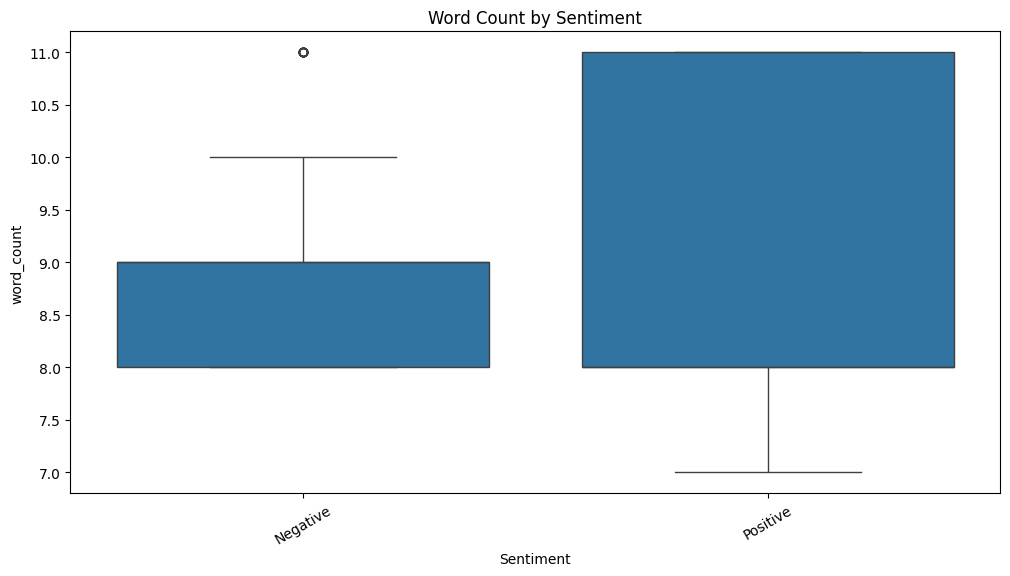

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Sentiment", y="word_count")
plt.title("Word Count by Sentiment")
plt.xticks(rotation=30)
plt.show()

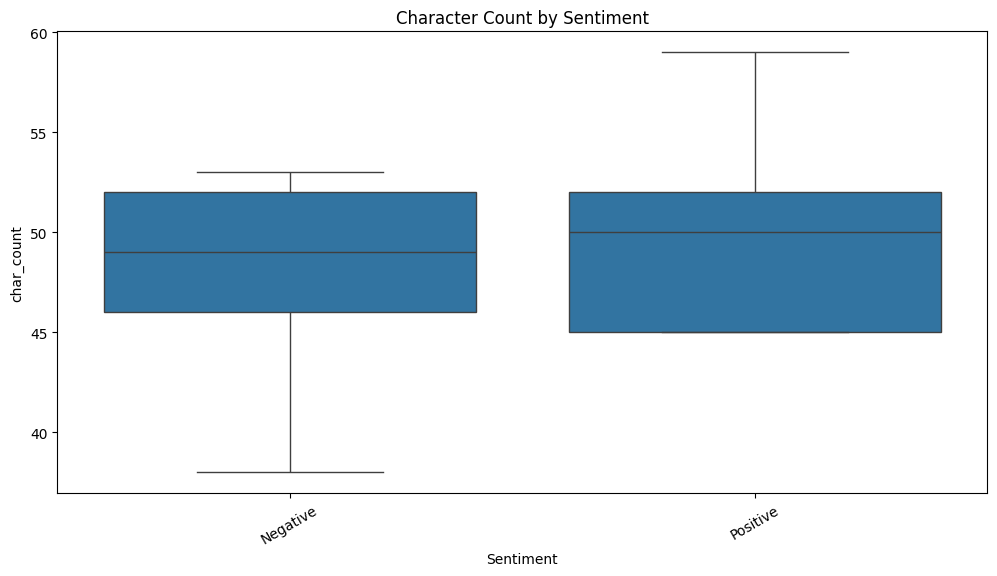

In [ ]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Sentiment", y="char_count")
plt.title("Character Count by Sentiment")
plt.xticks(rotation=30)
plt.show()

Month
June        172
May         133
October      43
July         41
November     39
December     37
March        35
Name: count, dtype: int64



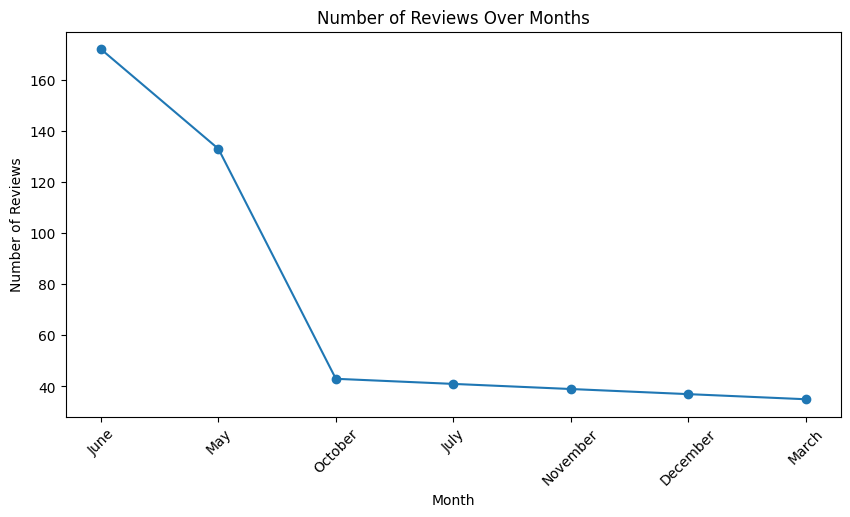

In [ ]:
monthly_reviews = df["Month"].value_counts()
print(f"{monthly_reviews}\n")

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

plt.figure(figsize=(10,5))

plt.plot(monthly_reviews.index, monthly_reviews.values, marker='o')

plt.title("Number of Reviews Over Months")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)
plt.show()

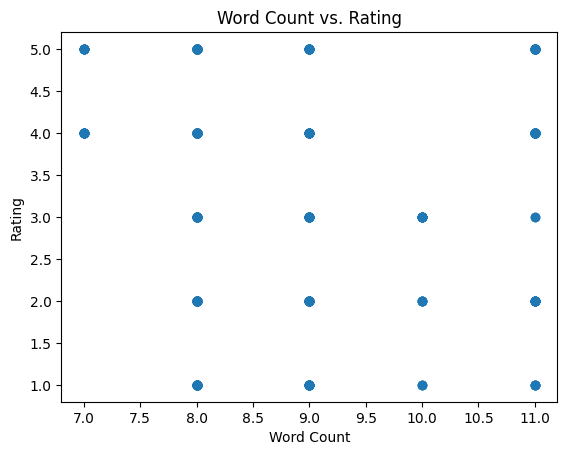

In [ ]:
plt.scatter(df["word_count"], df["Rating_Adjusted"])
plt.title("Word Count vs. Rating")
plt.xlabel("Word Count")
plt.ylabel("Rating")
plt.show()

In [ ]:
correlation = df["word_count"].corr(df["Rating"])
print("Correlation:", correlation)

Correlation: 0.05684754338460122


In [ ]:
import nltk
from nltk.corpus import stopwords
import string

# Define a simple list of stopwords
stop_words = set(["the", "is", "in", "and", "to", "a", "was", "for", "of", "on", "with", "at", "by", "an", "be", "this", "that", "or", "as", "i", "my", "had"])

# Function to remove stopwords
def remove_stopwords(text):
    words = text.lower().translate(str.maketrans('', '', string.punctuation)).split()
    return " ".join([word for word in words if word not in stop_words])

# Apply the function
df["clean_text"] = df["Review"].apply(remove_stopwords)

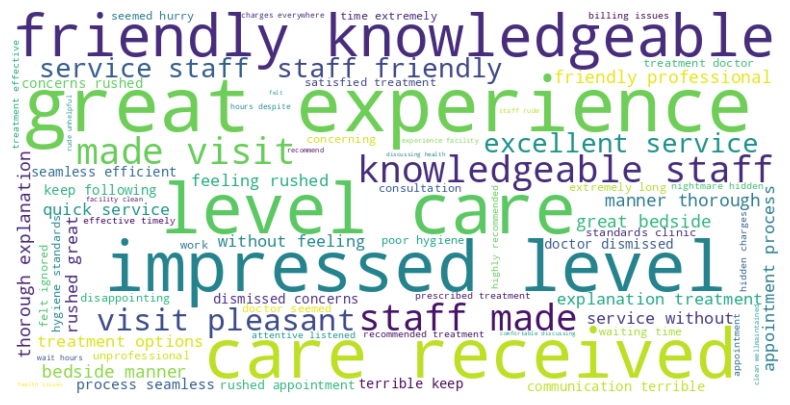

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(df["clean_text"]))

# Display the Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
positive_text = " ".join(df[df["Sentiment"]=="Positive"]["clean_text"])
negative_text = " ".join(df[df["Sentiment"]=="Negative"]["clean_text"])

positive_words = positive_text.split()
negative_words = negative_text.split()

In [ ]:
from collections import Counter

positive_freq = Counter(positive_words).most_common(20)
negative_freq = Counter(negative_words).most_common(20)

print("Top 20 Positive Words:")
print(positive_freq)

print("\nTop 20 Negative Words:")
print(negative_freq)

Top 20 Positive Words:
[('great', 78), ('very', 76), ('friendly', 64), ('staff', 64), ('service', 61), ('treatment', 52), ('experience', 48), ('impressed', 40), ('level', 40), ('care', 40), ('received', 40), ('knowledgeable', 33), ('made', 33), ('visit', 33), ('pleasant', 33), ('excellent', 31), ('professional', 31), ('bedside', 30), ('manner', 30), ('thorough', 30)]

Top 20 Negative Words:
[('very', 71), ('not', 62), ('doctor', 50), ('appointment', 49), ('treatment', 44), ('communication', 28), ('terrible', 28), ('keep', 28), ('following', 28), ('up', 28), ('dismissed', 28), ('concerns', 28), ('rushed', 28), ('felt', 25), ('ignored', 25), ('during', 25), ('consultation', 25), ('unprofessional', 25), ('waiting', 24), ('time', 24)]


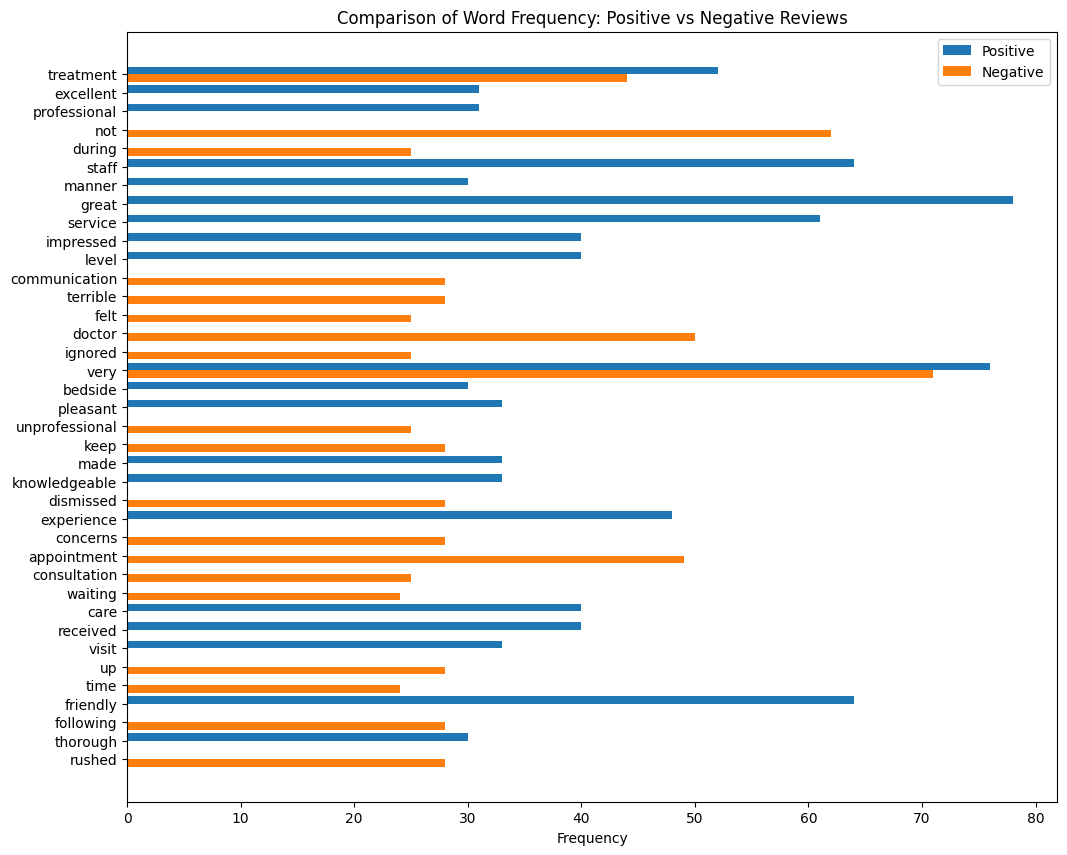

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Convertir en dictionnaires
pos_dict = dict(positive_freq)
neg_dict = dict(negative_freq)

all_words = list(set(list(pos_dict.keys()) + list(neg_dict.keys())))

# Fréquences correspondantes
pos_counts = [pos_dict.get(word, 0) for word in all_words]
neg_counts = [neg_dict.get(word, 0) for word in all_words]

y = np.arange(len(all_words))
height = 0.4

plt.figure(figsize=(12,10))

plt.barh(y - height/2, pos_counts, height=height, label="Positive")
plt.barh(y + height/2, neg_counts, height=height, label="Negative")

plt.yticks(y, all_words)

plt.xlabel("Frequency")
plt.title("Comparison of Word Frequency: Positive vs Negative Reviews")

plt.legend()
plt.gca().invert_yaxis()

plt.show()

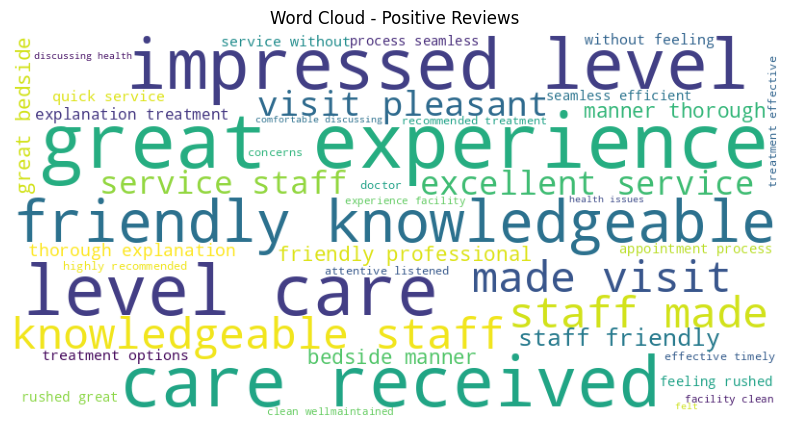

In [ ]:
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos)
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")
plt.show()

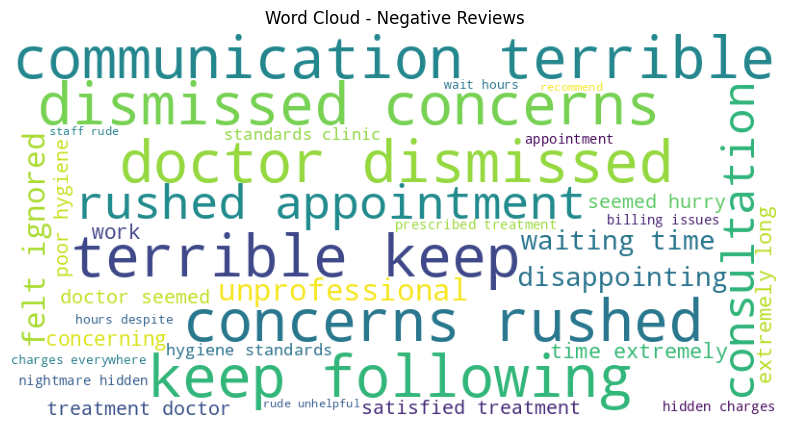

In [ ]:
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()

In [ ]:
location_rating = df.groupby("Location")["Rating_Adjusted"].mean().sort_values()
print(location_rating)

Location
Collinsport, OR           2.950000
Jessicahaven, WY          3.000000
West Brandyville, NC      3.058824
North Jose, NH            3.090909
New Alfred, MN            3.136364
Lopeztown, MS             3.142857
Millershire, NC           3.147059
Baileyhaven, ID           3.153846
Josephberg, NJ            3.233333
Lake Jenniferfurt, AR     3.250000
Lake Robert, WA           3.321429
Markfort, FL              3.323529
Reedborough, VT           3.375000
Collinsland, NH           3.407407
North Daniel, LA          3.666667
South Andrew, NJ          3.666667
Rubenview, SD             3.684211
Fuentesmouth, IN          3.722222
North Shawnborough, MT    3.772727
Petersonchester, MT       3.846154
Name: Rating_Adjusted, dtype: float64


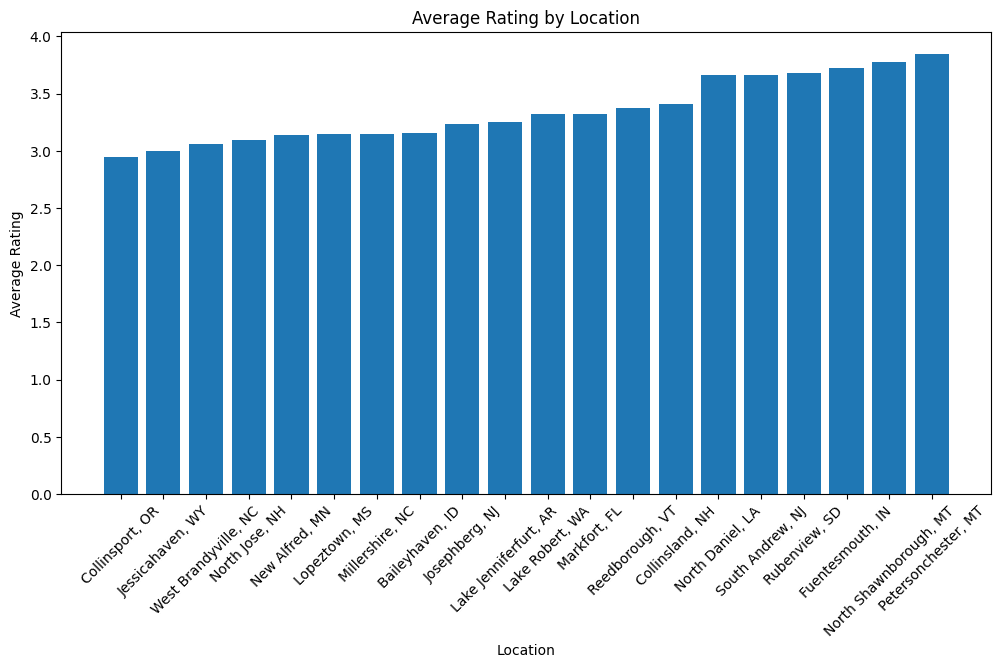

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(location_rating.index, location_rating.values)

plt.title("Average Rating by Location")
plt.xlabel("Location")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

In [ ]:
!pip install nbconvert

In [ ]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [ ]:
!apt-get update
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 https://cli.github.com/packages stable InRelease [3,917 B]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,749 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,613 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [70.9 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd6

In [ ]:
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/Assignement1_Louis_Keller.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Assignement1_Louis_Keller.ipynb to pdf
[NbConvertApp] Support files will be in Assignement1_Louis_Keller_files/
[NbConvertApp] Making directory ./Assignement1_Louis_Keller_files
[NbConvertApp] Writing 128266 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 926882 bytes to /content/drive/MyDrive/Colab Notebooks/Assignement1_Louis_Keller.pdf


In [ ]:
!jupyter nbconvert --to pdf --output Assignement1_Louis_Keller.pdf Assignement1_Louis_Keller.ipynb

[NbConvertApp] WARNING | pattern 'Assignement1_Louis_Keller.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]